In [1]:
%load_ext autoreload
%autoreload 2

# from src.datasets import *
from src.datamodule import KH9CdDataModule
from main import read_rois_from_geopackage
from torchgeo.datasets.utils import BoundingBox
import torch
import matplotlib.pyplot as plt

/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
aoi_test_small = BoundingBox(119736.8306800332211424,120771.4748695194866741,487192.3094612115528435,487754.0150268116849475,0,1)


old_images_dir = '/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced/'
old_images_dir = '/home/moritz/masterarbeit/raster/KH-9/amsterdam/georeferenced/filtered'
new_images_dir = '/home/moritz/masterarbeit/raster/aerial_images_2023'
bag_buildings_dir = '/home/moritz/masterarbeit/vector/buildings'
experiment_name = 'nb_test'
experiment_dir = 'nb_test'
log_dir = '/home/moritz/masterarbeit/early_fusion/logs'
batch_size = 2
patch_size = 256
learning_rate = 0.0001
num_dataloader_workers = 8
val_split_pct = 0.2
test_split_pct = 0.1
# checkpoint_name = args.checkpoint_name
rois = read_rois_from_geopackage('/home/moritz/masterarbeit/vector/dataset_splits.gpkg')
aoi = None
task = 'ChangeStarFarSeg'


## Datamodule and augmentation testing

In [3]:
datamodule = KH9CdDataModule(
    old_images_dir=old_images_dir,
    new_images_dir=new_images_dir,
    bag_buildings_dir=bag_buildings_dir,
    batch_size=batch_size,
    num_workers=num_dataloader_workers,
    patch_size=patch_size,
    val_split_pct=val_split_pct,
    test_split_pct=test_split_pct,
    rois=rois,
    aoi=aoi,
)

datamodule.setup("fit")

Converting AerialImages res from (0.25, 0.25) to (0.8811479302070964, 0.881147930124137)
Converting BagBuildings res from (0.0001, 0.0001) to (0.8811479302070964, 0.881147930124137)


In [4]:
from torchgeo.datasets import unbind_samples

loader = datamodule.train_dataloader()
batch = next(iter(loader))


In [7]:
from src.task import CustomSemanticSegmentationTask

model = CustomSemanticSegmentationTask(
    model='unet',
    backbone='resnet50',
    weights=True,
    in_channels=4,
    num_classes=2,
    loss="ce",
    ignore_index=99,
    lr=1e-4,
    patience=10,
)
model.eval()


CustomSemanticSegmentationTask(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

AttributeError: 'NoneType' object has no attribute 'experiment'

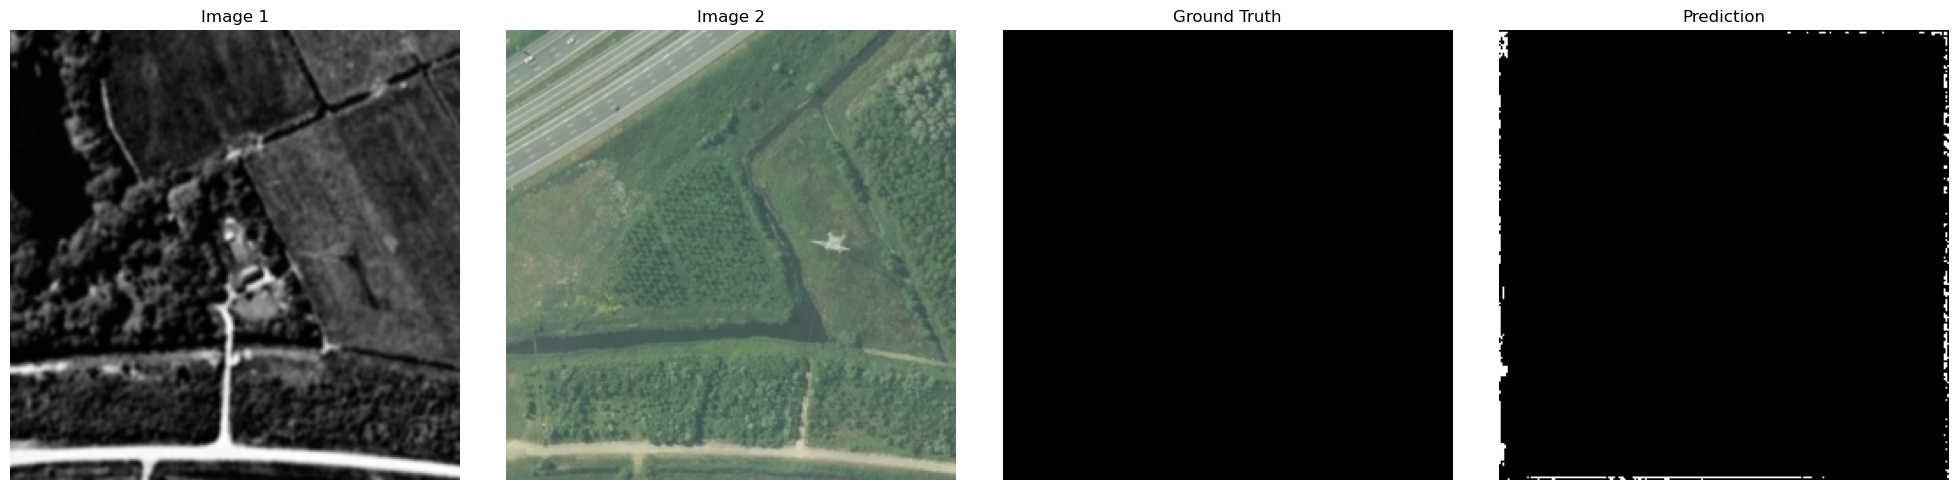

In [8]:
import copy

# Re-fetch fresh batch generator
dataloader = datamodule.train_dataloader()
iterator = iter(dataloader)

for idx in range(10):
    batch = next(iterator)
    batch_copy = copy.deepcopy(batch)  # Prevent mutation
    loss = model.training_step(batch_copy, idx)
    print(f"Step {idx} - Loss: {loss.item():.4f}")


## DualEncoderChangeDetectionTask Model Test
Test the custom dual-encoder model on a few batches from the datamodule.

In [5]:
from src.task import DualEncoderChangeDetectionTask

dual_encoder_model = DualEncoderChangeDetectionTask(
    encoder_old_name="resnet18",
    encoder_new_name="resnet18",
    num_classes=2,
    lr=1e-4,
    pretrained=True,
)
dual_encoder_model.eval()

/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DualEncoderChangeDetectionTask(
  (encoder_old): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=

In [6]:
import copy

dataloader = datamodule.train_dataloader()
iterator = iter(dataloader)

for idx in range(5):
    batch = next(iterator)
    batch_copy = copy.deepcopy(batch)
    loss = dual_encoder_model.training_step(batch_copy, idx)
    print(f"DualEncoder Step {idx} - Loss: {loss.item():.4f}")

/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/lightning/pytorch/core/module.py:419: UserWarning: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`
  rank_zero_warn(
/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torch/nn/functional.py:5082: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


DualEncoder Step 0 - Loss: 0.7580


/home/moritz/miniforge3/envs/torchgeo/lib/python3.12/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


DualEncoder Step 1 - Loss: 0.7845
DualEncoder Step 2 - Loss: 0.6614
DualEncoder Step 3 - Loss: 0.7228
DualEncoder Step 4 - Loss: 0.6677
